# Visual robustness check: predictions on strongly rotated/augmented images

`val`/`test` splits are evaluated on **plain, unaugmented** crops (deterministic
`build_eval_transform`, see `wings/dataset.py`) -- that's correct for tracking
comparable `val_mean_error_px` across epochs, but it never actually shows what
the model does on the kind of heavily rotated, noisy input it was trained to
handle (`TrainAugmentConfig`, see `jobs/online/README.md`). This notebook runs
inference on **test** images pushed through controlled rotation angles and
through the *actual* config 4 augmentation severity, and overlays predicted
(red x) vs. ground-truth (green o) landmarks so you can see it directly. Test
(not validation) is used deliberately here: validation is what training
selects/early-stops checkpoints against, so it's the set most likely to be
implicitly "tuned to" -- test is the untouched holdout.

**Before trusting these specific numbers:** point `CHECKPOINT_PATH` below at
config 4's actual trained checkpoint (copy it down from the HPC --
`wings/modeling/training/lightning-checkpoints/unet-400-online-augmentation-k5-4/`
on the cluster). It currently falls back to `unet-final-k5.ckpt` (the
pre-fine-tuning checkpoint) purely so this notebook runs and is verified
end-to-end locally -- the mechanics are correct, but that specific checkpoint
was never trained on this augmentation, so its robustness numbers below don't
reflect config 4.

## Setup

In [20]:
import random

import torch
import matplotlib.pyplot as plt
import numpy as np

from wings.config import PROCESSED_DATA_DIR, MODELS_DIR, COUNTRIES
from wings.dataset import WingsRawDataset, TransformedMaskDataset
from wings.transforms import TrainAugmentConfig, build_train_transform, build_eval_transform
from wings.visualizing.image_preprocess import mask_to_coords
from wings.gpa import handle_coordinates
from wings.modeling.unet import UNet
from wings.modeling.litnet import LitNet
from wings.modeling.loss import BCEDiceLoss

torch.manual_seed(0)

# --- Update these two once you have config 4's real checkpoint ---
CHECKPOINT_PATH = MODELS_DIR / "new_unet" / "unet-final-k5.ckpt"
CHECKPOINT_PATH = MODELS_DIR / "online" / "last.ckpt"
MODEL_SIGMOID = False  # config 4 uses BCEDiceLoss -> UNet(sigmoid=False); flip to True for a config 1/3 checkpoint
# -------------------------------------------------------------------

OUTPUT_SIZE = 400
SQUARE_SIZE = 5

## Load model + test split

Same raw source and the same `seed=42` split the real training run uses, so
`test_idx` here is exactly the held-out test set config 4 was never scored
against during training/early-stopping decisions.

In [21]:
mean_coords = torch.load(
    PROCESSED_DATA_DIR / "mask_datasets" / "rectangle" / "mean_shape.pth", weights_only=False
)

model = UNet(in_channels=1, out_channels=1, kernel_size=5, sigmoid=MODEL_SIGMOID)
lit_net = LitNet.load_from_checkpoint(
    CHECKPOINT_PATH,
    model=model,
    criterion=BCEDiceLoss(),  # unused for inference, LitNet just requires one
    num_epochs=1,
    mean_coords=mean_coords,
    strict=False,
)
lit_net.eval()
device = lit_net.device
print(f"Loaded checkpoint: {CHECKPOINT_PATH.name}")

raw = WingsRawDataset(COUNTRIES, PROCESSED_DATA_DIR / "cropped")
_, _, test_idx = raw.split(val_percentage=0.2, test_percentage=0.1, seed=42)
print(f"Test samples available: {len(test_idx)}")

Loaded checkpoint: last.ckpt


100%|██████████| 21722/21722 [00:00<00:00, 168731.95it/s]

Test samples available: 2172


## Helper functions

In [22]:
def predict_mask_coords(image_tensor):
    """image_tensor: (1, H, W), already normalized. Returns predicted
    landmark points in bottom-left convention (same as mask_to_coords/
    mean_coords everywhere else in this codebase)."""
    with torch.no_grad():
        output = lit_net.model(image_tensor.unsqueeze(0).to(device))
    probs = output if MODEL_SIGMOID else torch.sigmoid(output)
    pred_mask = (probs > 0.5).float().squeeze().cpu().numpy()
    return mask_to_coords(pred_mask)


def to_plot_xy(coords, img_size):
    """mask_to_coords returns bottom-left (x, y); flip y back for correct
    overlay on a top-left-origin imshow."""
    return [(x, img_size - y - 1) for x, y in coords]


def matched_distances(pred_coords, true_coords):
    """Independently reorders predicted and ground-truth points to the
    canonical mean-shape ordering (same approach litnet.py's
    compute_statistics uses for pred_coords), then returns per-landmark
    distances. Returns None if either side doesn't have a clean 19-point
    match (common under extreme augmentation -- skip rather than guess)."""
    if len(pred_coords) == 0 or len(true_coords) == 0:
        return None
    try:
        pred_t = torch.tensor(pred_coords, dtype=torch.float32)
        true_t = torch.tensor(true_coords, dtype=torch.float32)
        pred_r = handle_coordinates(pred_t, mean_coords).detach().float()
        true_r = handle_coordinates(true_t, mean_coords).detach().float()
        if pred_r.shape != true_r.shape:
            return None
        return torch.norm(pred_r - true_r, dim=1)
    except Exception:
        return None


def run_sample(base_index, transform):
    """Runs one raw test sample through `transform`, returning the
    transformed image + its ground-truth mask (built the identical way
    training builds it, via TransformedMaskDataset) plus decoded pred/true
    coordinates."""
    ds = TransformedMaskDataset(test_idx, transform, square_size=SQUARE_SIZE)
    image, target_mask, _, _ = ds[base_index]
    pred_coords = predict_mask_coords(image)
    true_coords = mask_to_coords(target_mask.squeeze(0).numpy())
    return image, pred_coords, true_coords


def overlay(ax, image, pred_coords, true_coords, title):
    img_size = image.shape[-1]
    ax.imshow(image.squeeze(0).numpy(), cmap="gray")
    if true_coords:
        tx, ty = zip(*to_plot_xy(true_coords, img_size))
        ax.scatter(tx, ty, s=160, facecolors="none", edgecolors="lime", linewidths=2.2, label="ground truth")
    if pred_coords:
        px, py = zip(*to_plot_xy(pred_coords, img_size))
        ax.scatter(px, py, c="red", s=90, marker="x", linewidths=2.2, label="predicted")
    ax.set_title(f"{title} (gt={len(true_coords)}, pred={len(pred_coords)})", fontsize=13)
    ax.legend(loc="upper right", fontsize=10)
    ax.axis("off")


def show_one(image, pred_coords, true_coords, title):
    """One large figure per image, shown immediately -- rendered one after
    another in the notebook rather than packed into a row."""
    fig, ax = plt.subplots(figsize=(6, 6))
    overlay(ax, image, pred_coords, true_coords, title)
    plt.tight_layout()
    plt.show()


# Config 4's actual training-time augmentation ("Aug B", jobs/online/README.md).
# Reused below by both the fixed random-draw grid and the re-runnable cell --
# each call to this transform draws fresh random parameters, it's not a
# one-time sample.
aug_b_cfg = TrainAugmentConfig(
    rotation_degrees=(-90.0, 90.0),
    triangle_noise_p=0.8,
    n_triangles_range=(40, 240),
    color_jitter_p=1.0,
    color_jitter_brightness_range=(0.5, 1.5),
    color_jitter_contrast_range=(0.5, 1.5),
)
aug_b_transform = build_train_transform(OUTPUT_SIZE, aug_b_cfg)

## Section A -- fixed rotation angle sweep

Pure rotation only (no noise/jitter), on a single test image, to isolate how
rotation alone affects predictions. Each angle is its own full-size figure,
shown one after another below.

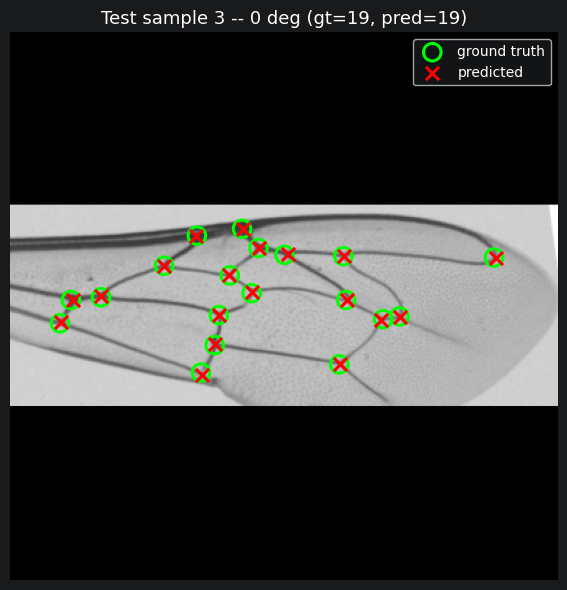

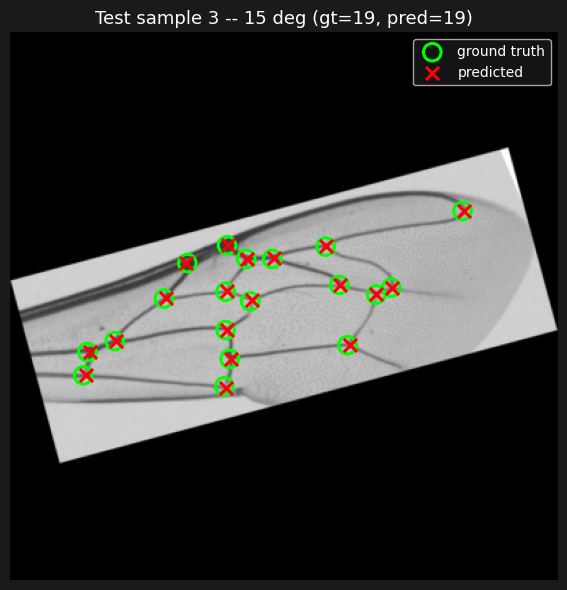

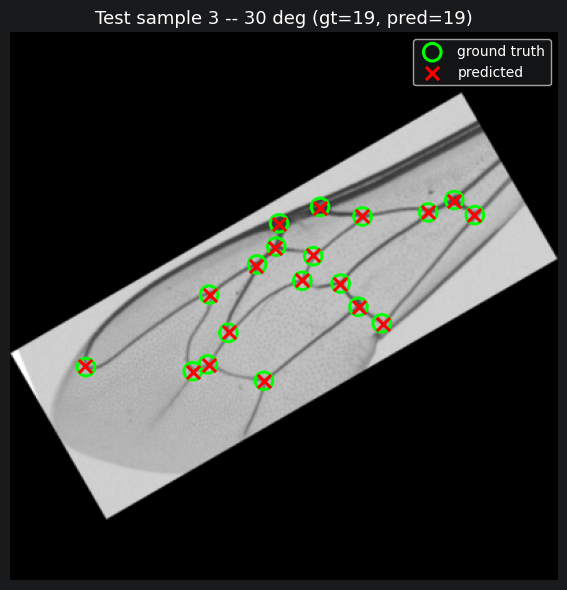

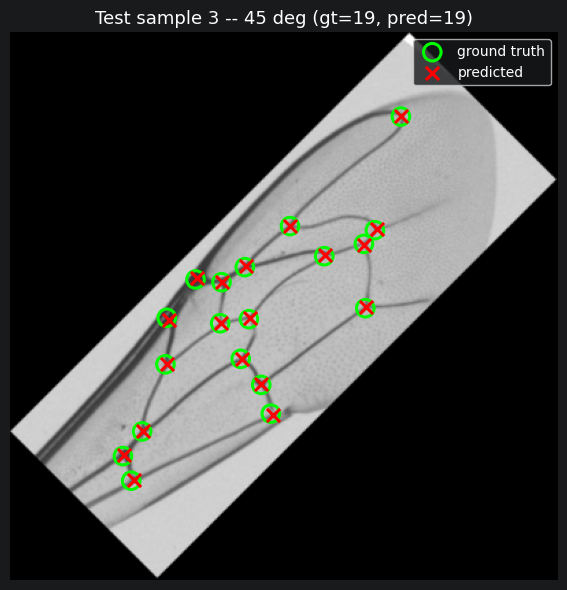

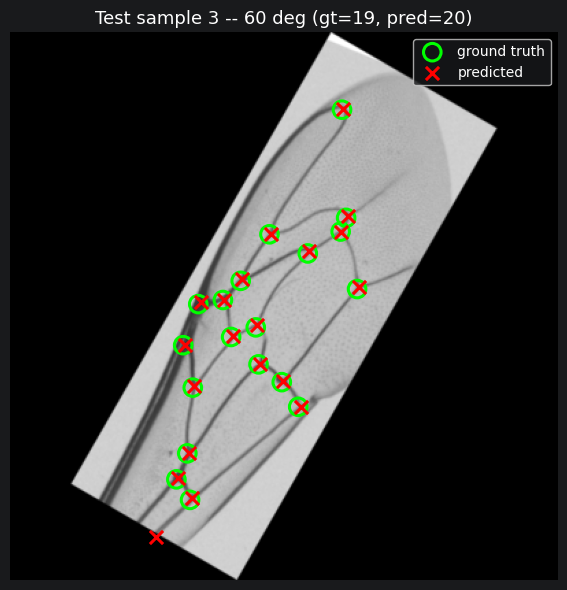

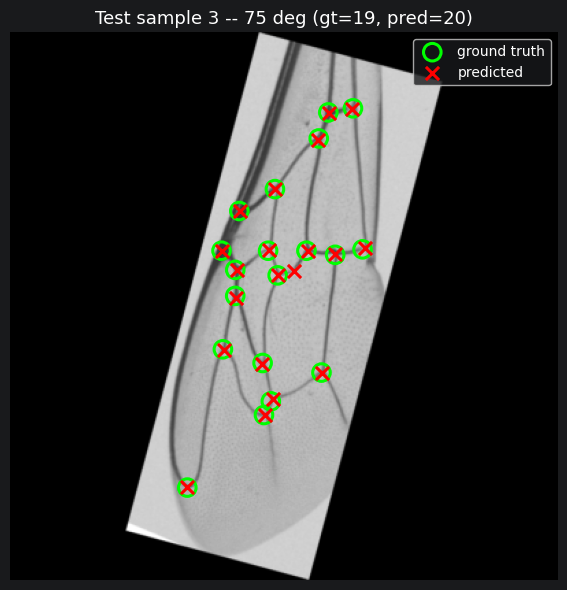

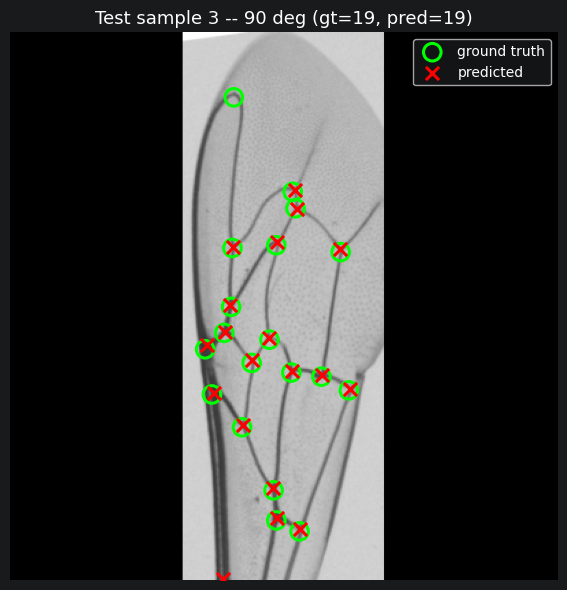

In [23]:
sample_index = 3
angles = [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0]

for angle in angles:
    cfg = TrainAugmentConfig(rotation_degrees=(angle, angle), triangle_noise_p=0.0, color_jitter_p=0.0)
    image, pred_coords, true_coords = run_sample(sample_index, build_train_transform(OUTPUT_SIZE, cfg))
    show_one(image, pred_coords, true_coords, f"Test sample {sample_index} -- {angle:.0f} deg")

## Section B -- realistic worst case: full config 4 augmentation severity

Same `TrainAugmentConfig` config 4 actually trains on (`jobs/online/README.md`
"Aug B"): rotation +/-90 deg, triangle noise 80% of the time (40-240
triangles), color jitter 100% of the time (0.5-1.5x brightness/contrast).
Each image is an independent random draw -- exactly what the model saw during
training, not a cherry-picked easy case -- shown one after another below.

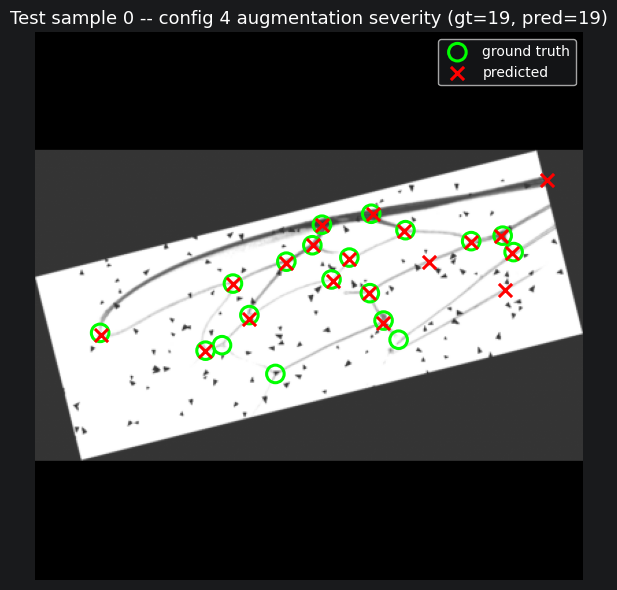

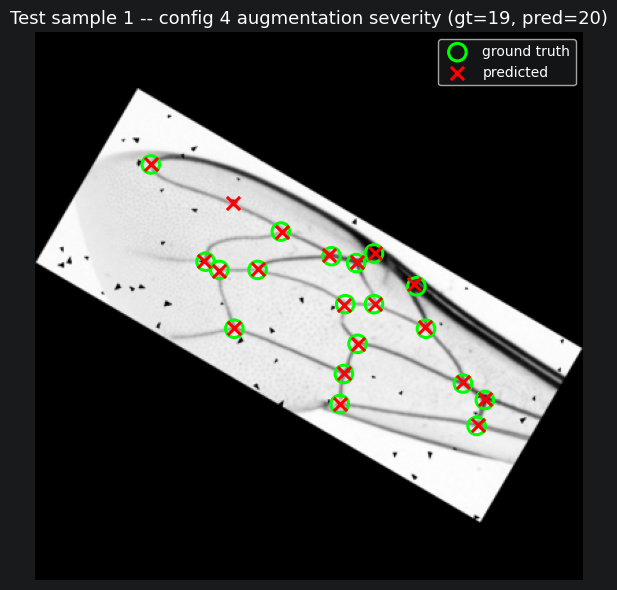

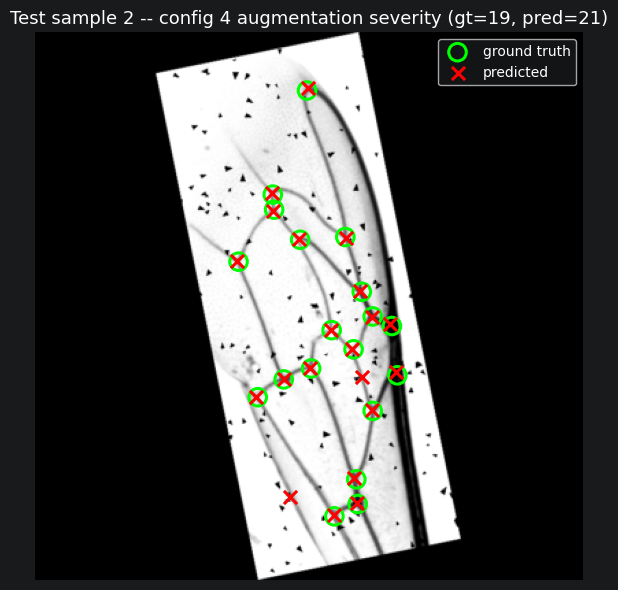

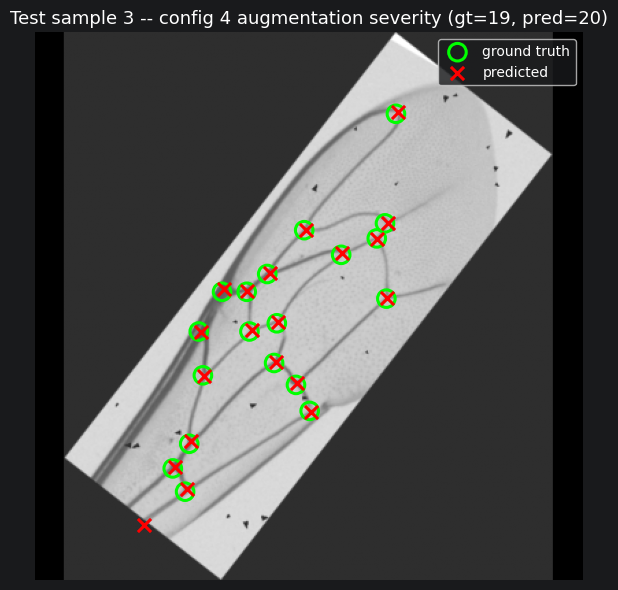

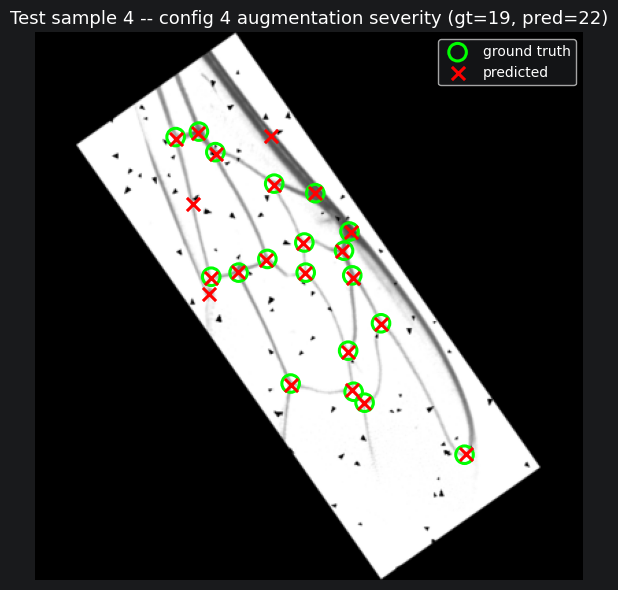

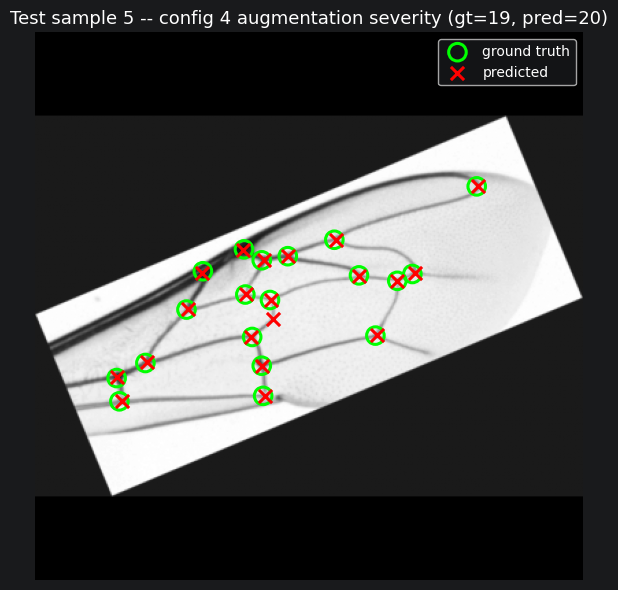

In [24]:
sample_indices = [0, 1, 2, 3, 4, 5]
for idx in sample_indices:
    image, pred_coords, true_coords = run_sample(idx, aug_b_transform)
    show_one(image, pred_coords, true_coords, f"Test sample {idx} -- config 4 augmentation severity")

## Section C -- error vs. rotation angle (quantitative)

Averages matched per-landmark pixel error across several test samples at each
fixed rotation angle (no noise/jitter, isolating rotation's effect). Samples
where the predicted or ground-truth mask doesn't cleanly decode to a point set
are skipped rather than guessed at (this itself is informative -- see the
"skipped" count printed per angle).

angle=  0.0  mean_error_px=3.944  skipped=0/15
angle= 15.0  mean_error_px=2.781  skipped=0/15
angle= 30.0  mean_error_px=5.826  skipped=0/15
angle= 45.0  mean_error_px=9.999  skipped=0/15
angle= 60.0  mean_error_px=19.419  skipped=0/15
angle= 75.0  mean_error_px=16.061  skipped=0/15
angle= 90.0  mean_error_px=113.621  skipped=0/15


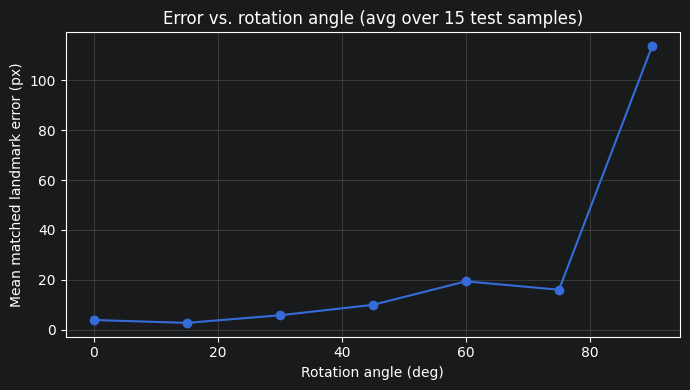

In [25]:
angles = [0.0, 15.0, 30.0, 45.0, 60.0, 75.0, 90.0]
n_samples = 15

mean_errors = []
skipped_counts = []
for angle in angles:
    cfg = TrainAugmentConfig(rotation_degrees=(angle, angle), triangle_noise_p=0.0, color_jitter_p=0.0)
    transform = build_train_transform(OUTPUT_SIZE, cfg)
    distances = []
    skipped = 0
    for idx in range(n_samples):
        _, pred_coords, true_coords = run_sample(idx, transform)
        d = matched_distances(pred_coords, true_coords)
        if d is None:
            skipped += 1
        else:
            distances.append(d.mean().item())
    mean_errors.append(np.mean(distances) if distances else float("nan"))
    skipped_counts.append(skipped)
    print(f"angle={angle:>5.1f}  mean_error_px={mean_errors[-1]:.3f}  skipped={skipped}/{n_samples}")

plt.figure(figsize=(7, 4))
plt.plot(angles, mean_errors, marker="o")
plt.xlabel("Rotation angle (deg)")
plt.ylabel("Mean matched landmark error (px)")
plt.title(f"Error vs. rotation angle (avg over {n_samples} test samples)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section D -- interactive: re-run for a new random example

**Just re-run this cell** (select it, press Ctrl+Enter / the Run button)
repeatedly -- each execution picks a different random test image and a fresh
random draw of config 4's actual augmentation (new rotation angle, new
triangle noise, new color jitter), runs the model, and shows the overlay. No
setup needed beyond running the cells above once.

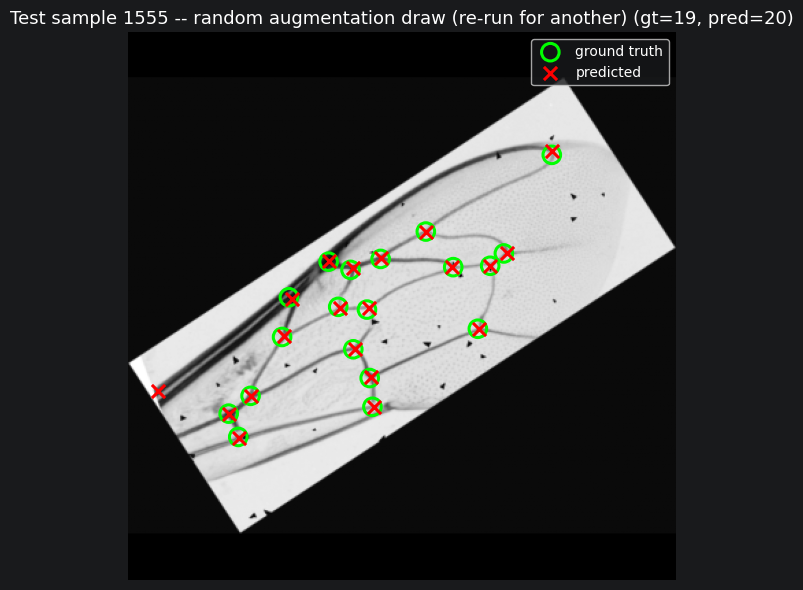

In [47]:
idx = random.randrange(len(test_idx))
image, pred_coords, true_coords = run_sample(idx, aug_b_transform)
show_one(image, pred_coords, true_coords, f"Test sample {idx} -- random augmentation draw (re-run for another)")

## Summary

- Section A shows whether error visibly grows with rotation magnitude for one
  fixed sample -- a rising red-x/green-o gap at 60-90 deg vs. 0 deg would flag
  the model is still weaker on extreme angles despite training on them.
- Section B is the realistic check: this is the actual distribution the model
  trains on, so this is the most representative "how good is it really" view.
- Section C turns that into a number: a roughly flat line across angles means
  rotation robustness is genuinely learned; a line that climbs steeply past
  some angle pinpoints where it breaks down.
- Section D is for freely browsing -- keep re-running it to build intuition
  across many random test images/augmentation draws.
- Remember to swap `CHECKPOINT_PATH` for config 4's real checkpoint before
  drawing conclusions from the actual numbers here.